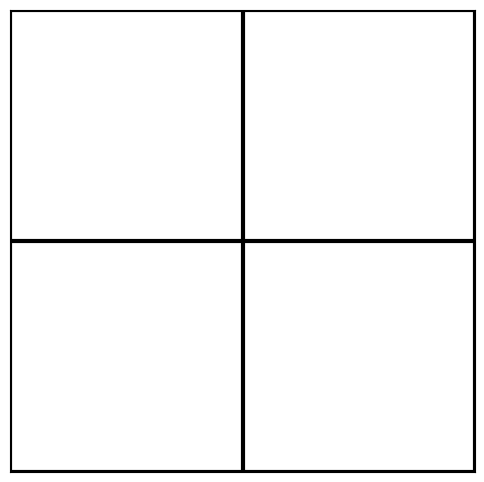

In [1]:
from sudoku_nisq.q_sudoku import QSudoku

puzzle = QSudoku.generate(size=2, num_missing_cells=4)
puzzle.plot_puzzle()

In [2]:
puzzle.subgrid_size

1

In [3]:
from sudoku_nisq import ExactCoverQuantumSolver

puzzle.set_solver(ExactCoverQuantumSolver, encoding="pattern")


In [4]:
circuit = puzzle.build_circuit(sdk="pytket")

In [5]:
puzzle.draw_circuit()

In [6]:
circuit.n_qubits

29

In [7]:
circuit.n_gates

286

In [8]:
circuit.depth()

102

In [9]:
circuit1 = puzzle.build_circuit(sdk="qiskit")

In [10]:
circuit1.draw()

┌───┐┌─────────┐            ┌────────────┐┌───────────┐┌─────────┐»
   S_0: ┤ H ├┤0        ├────────────┤0           ├┤0          ├┤0        ├»
        ├───┤│         │            │            ││           ││         │»
   S_1: ┤ H ├┤1        ├────────────┤1           ├┤1          ├┤1        ├»
        ├───┤│         │            │            ││  DIFFUSER ││         │»
   S_2: ┤ H ├┤2        ├────────────┤2           ├┤2          ├┤2        ├»
        ├───┤│         │            │            ││           ││         │»
   S_3: ┤ H ├┤3        ├────────────┤3           ├┤3          ├┤3        ├»
        └───┘│         │┌──────────┐│            │└───────────┘│         │»
 U_0_0: ─────┤4        ├┤0         ├┤4           ├─────────────┤4        ├»
             │         ││          ││            │             │         │»
 U_0_1: ─────┤5        ├┤1         ├┤5           ├─────────────┤5        ├»
             │         ││          ││            │             │         │»
 U_1_0: ─────┤6        ├┤2         ├┤6           ├─────────────┤6        ├»
             │         ││          ││            │             │         │»
 U_1_1: ─────┤7        ├┤3         ├┤7           ├─────────────┤7        ├»
             │         ││          ││            │             │         │»
 U_2_0: ─────┤8        ├┤4         ├┤8           ├─────────────┤8        ├»
             │         ││          ││            │             │         │»
 U_2_1: ─────┤9        ├┤5         ├┤9           ├─────────────┤9        ├»
             │         ││          ││            │             │         │»
 U_3_0: ─────┤10       ├┤6         ├┤10          ├─────────────┤10       ├»
             │         ││          ││            │             │         │»
 U_3_1: ─────┤11       ├┤7         ├┤11          ├─────────────┤11       ├»
             │         ││          ││            │             │         │»
 U_4_0: ─────┤12       ├┤8         ├┤12          ├─────────────┤12       ├»
             │         ││          ││            │             │         │»
 U_4_1: ─────┤13       ├┤9         ├┤13          ├─────────────┤13       ├»
             │   COUNT ││          ││   COUNT_dg │             │   COUNT │»
 U_5_0: ─────┤14       ├┤10        ├┤14          ├─────────────┤14       ├»
             │         ││          ││            │             │         │»
 U_5_1: ─────┤15       ├┤11        ├┤15          ├─────────────┤15       ├»
             │         ││          ││            │             │         │»
 U_6_0: ─────┤16       ├┤12 ORACLE ├┤16          ├─────────────┤16       ├»
             │         ││          ││            │             │         │»
 U_6_1: ─────┤17       ├┤13        ├┤17          ├─────────────┤17       ├»
             │         ││          ││            │             │         │»
 U_7_0: ─────┤18       ├┤14        ├┤18          ├─────────────┤18       ├»
             │         ││          ││            │             │         │»
 U_7_1: ─────┤19       ├┤15        ├┤19          ├─────────────┤19       ├»
             │         ││          ││            │             │         │»
 U_8_0: ─────┤20       ├┤16        ├┤20          ├─────────────┤20       ├»
             │         ││          ││            │             │         │»
 U_8_1: ─────┤21       ├┤17        ├┤21          ├─────────────┤21       ├»
             │         ││          ││            │             │         │»
 U_9_0: ─────┤22       ├┤18        ├┤22          ├─────────────┤22       ├»
             │         ││          ││            │             │         │»
 U_9_1: ─────┤23       ├┤19        ├┤23          ├─────────────┤23       ├»
             │         ││          ││            │             │         │»
U_10_0: ─────┤24       ├┤20        ├┤24          ├─────────────┤24       ├»
             │         ││          ││            │             │         │»
U_10_1: ─────┤25       ├┤21        ├┤25          ├─────────────┤25       ├»
             │         ││          ││            │      

In [11]:
from qiskit import QuantumCircuit

def count_gates(circ: QuantumCircuit) -> int:
    count = 0
    for instr in circ.data:
        op = instr.operation      # was: inst
        # qubits = instr.qubits   # if you need them
        # clbits = instr.clbits   # if you need them

        if op.name == "barrier":  # optional filter
            continue
        count += 1
    return count


In [12]:
from collections import Counter
from qiskit import QuantumCircuit

def gate_counts(circ: QuantumCircuit) -> Counter:
    counts = Counter()
    for instr in circ.data:
        op = instr.operation
        if op.name == "barrier":  # optional filter
            continue
        counts[op.name] += 1
    return counts

counts = gate_counts(circuit1)
print(counts)


Counter({'h': 5, 'measure': 4, 'COUNT': 2, 'ORACLE': 2, 'COUNT_dg': 2, 'DIFFUSER': 2, 'x': 1})


In [13]:
ignored = {"barrier", "measure"}
total = sum(c for g, c in counts.items() if g not in ignored)
print(total)

14


# Generate Qiskit and PyTKET circuits

This section builds circuits for both "simple" and "pattern" encodings using PyTKET and Qiskit. If Qiskit isn’t installed, the Qiskit cells will print a helpful hint.

In [15]:
# Helpers for setting the solver and summarizing circuits
from sudoku_nisq import ExactCoverQuantumSolver, ExactCoverEncoding
from sudoku_nisq.sudoku_pattern_generation import PatternGeneration


def set_exact_cover_solver_for(puzzle, encoding: str = "simple"):
    """Set ExactCover solver on `puzzle` for the requested encoding.
    Handles the 2x2 special case by injecting 2x2-specific universe/subsets.
    Returns the active solver.
    """
    if puzzle.subgrid_size >= 2:
        puzzle.set_solver(ExactCoverQuantumSolver, encoding=encoding)
        return puzzle._solver
    # 2x2 special-case: use 2x2 universe/subsets helpers
    enc = ExactCoverEncoding(puzzle.puzzle)
    if encoding == "simple":
        subsets = enc.gen_simple_subsets2x2()
    elif encoding == "pattern":
        pat = PatternGeneration(puzzle.puzzle)
        subsets = enc.gen_patterns_subsets2x2(pat.patterns, puzzle.puzzle.pre_tuples)
    else:
        raise ValueError(f"Unknown encoding: {encoding}")
    puzzle.set_solver(
        ExactCoverQuantumSolver,
        encoding=encoding,
        universe=getattr(enc, "universe2x2", []),
        subsets=subsets,
    )
    return puzzle._solver


def summarize_circuit(circ):
    try:
        # pytket Circuit
        n_qubits = getattr(circ, "n_qubits", None)
        n_gates = getattr(circ, "n_gates", None)
        if n_qubits is not None and n_gates is not None:
            print(f"Circuit summary (PyTKET): qubits={n_qubits}, gates={n_gates}")
            return
        # Qiskit QuantumCircuit
        from qiskit.circuit import QuantumCircuit  # type: ignore
        if isinstance(circ, QuantumCircuit):
            gate_count = sum(circ.count_ops().values()) if hasattr(circ, 'count_ops') else None
            print(f"Circuit summary (Qiskit): qubits={circ.num_qubits}, gates={gate_count}")
            return
    except Exception:
        pass
    # Fallback
    print(f"Circuit built: type={type(circ)}")

## Simple Encoding — PyTKET

In [16]:
# Build PyTKET circuit for simple encoding
solver_simple = set_exact_cover_solver_for(puzzle, encoding="simple")
ptk_simple = puzzle.build_circuit()
summarize_circuit(ptk_simple)
# Optional: visualize in notebooks with pytket's renderer
puzzle.draw_circuit(ptk_simple)

Circuit summary (PyTKET): qubits=45, gates=1826


Circuit summary (PyTKET): qubits=45, gates=1826


## Simple Encoding — Qiskit

In [17]:
# Build Qiskit circuit for simple encoding
try:
    import qiskit as qk
    qk_simple = puzzle._solver.build_main_circuit(backend=qk)
    summarize_circuit(qk_simple)
    try:
        # Text drawer avoids mpl dependency
        print(qk_simple.draw(output="text"))
    except Exception:
        pass
except ImportError:
    print("Qiskit not available. Install with: pip install qiskit")

Circuit summary (Qiskit): qubits=45, gates=50
        ┌───┐┌─────────┐            ┌────────────┐┌───────────┐┌─────────┐»
   S_0: ┤ H ├┤0        ├────────────┤0           ├┤0          ├┤0        ├»
        ├───┤│         │            │            ││           ││         │»
   S_1: ┤ H ├┤1        ├────────────┤1           ├┤1          ├┤1        ├»
        ├───┤│         │            │            ││           ││         │»
   S_2: ┤ H ├┤2        ├────────────┤2           ├┤2          ├┤2        ├»
        ├───┤│         │            │            ││           ││         │»
   S_3: ┤ H ├┤3        ├────────────┤3           ├┤3          ├┤3        ├»
        ├───┤│         │            │            ││  DIFFUSER ││         │»
   S_4: ┤ H ├┤4        ├────────────┤4           ├┤4          ├┤4        ├»
        ├───┤│         │            │            ││           ││         │»
   S_5: ┤ H ├┤5        ├────────────┤5           ├┤5          ├┤5        ├»
        ├───┤│         │            │     

## Pattern Encoding — PyTKET

In [18]:
# Build PyTKET circuit for pattern encoding
solver_pattern = set_exact_cover_solver_for(puzzle, encoding="pattern")
ptk_pattern = puzzle.build_circuit()
summarize_circuit(ptk_pattern)
# Optional: visualize
# puzzle.draw_circuit(ptk_pattern)

Circuit summary (PyTKET): qubits=29, gates=18


## Pattern Encoding — Qiskit

In [19]:
# Build Qiskit circuit for pattern encoding
try:
    import qiskit as qk  # type: ignore
    qk_pattern = puzzle._solver.build_main_circuit(backend=qk)
    summarize_circuit(qk_pattern)
    try:
        print(qk_pattern.draw(output="text"))
    except Exception:
        pass
except ImportError:
    print("Qiskit not available. Install with: pip install qiskit")

Circuit summary (Qiskit): qubits=29, gates=18
        ┌───┐┌─────────┐            ┌────────────┐┌───────────┐┌─────────┐»
   S_0: ┤ H ├┤0        ├────────────┤0           ├┤0          ├┤0        ├»
        ├───┤│         │            │            ││           ││         │»
   S_1: ┤ H ├┤1        ├────────────┤1           ├┤1          ├┤1        ├»
        ├───┤│         │            │            ││  DIFFUSER ││         │»
   S_2: ┤ H ├┤2        ├────────────┤2           ├┤2          ├┤2        ├»
        ├───┤│         │            │            ││           ││         │»
   S_3: ┤ H ├┤3        ├────────────┤3           ├┤3          ├┤3        ├»
        └───┘│         │┌──────────┐│            │└───────────┘│         │»
 U_0_0: ─────┤4        ├┤0         ├┤4           ├─────────────┤4        ├»
             │         ││          ││            │             │         │»
 U_0_1: ─────┤5        ├┤1         ├┤5           ├─────────────┤5        ├»
             │         ││          ││     